# Mediciones en hardware IBM

In [1]:
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService,\
                               SamplerV2 as Sampler,\
                               EstimatorV2 as Estimator
import numpy as np

In [20]:
# Save your API key and CRN to track your progress
# and have access to the IBM's Quantum Computers

# Define the API Key
your_api_key = "ska_G7pd6pH8WMj4Q94rCh-_DC-yQb0Hc-a4meib-OuH"

# Define the CRN code
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/fa4aa19182674fc48bcfbe7d02958cce:0e22a8a1-2732-4273-8716-baf22253a332::"


# Import Qiskit's Runtime Service
# from the Qiskit's IBM Runtime library
from qiskit_ibm_runtime import QiskitRuntimeService


# Save the account's information on
# the Qiskit's Runtime Service
QiskitRuntimeService.save_account\
(
    token = your_api_key,
    instance = your_crn,
    name = "prove",
    overwrite = True
)

In [21]:
# Check that the account has been saved properly

# Retrieve the Qiskit's Runtime Service
service = QiskitRuntimeService(name = "prove")

# Retrieve and show the saved accounts
# from the Qiskit's Runtime Service
service.saved_accounts()

management.get:WARNING:2025-10-18 10:21:11,486: Loading saved account: prove


{'prove': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': 'ska_G7pd6pH8WMj4Q94rCh-_DC-yQb0Hc-a4meib-OuH',
  'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/fa4aa19182674fc48bcfbe7d02958cce:0e22a8a1-2732-4273-8716-baf22253a332::',
  'verify': True,
  'private_endpoint': False}}

In [24]:
# Retrieve a backend which is operational
# and is not a simulator, being the least busy one,
# in order to get access to a real quantum computer with a QPU
backend = service.least_busy(operational = True,
                             simulator = False)

estimator = Estimator(mode=backend)
 
estimator.options.max_execution_time = 60

# Print a log message with the real quantum computer
# with a QPU which we are accessing through the cloud
print(f"We are using the {backend.name} Quantum Computer!")

We are using the ibm_torino Quantum Computer!


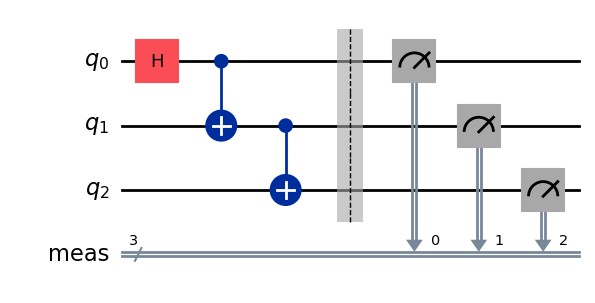

In [25]:
# Step 1. Map

# You should have created a GHZ Circuit above
# and assigned with variable `qc`
qc = QuantumCircuit(3)

# Add a H (Hadamard) gate to qubit 0
qc.h(0)

# Add a CNOT (Controlled-Not) gate to
# qubits 0 (control) and 1 (target)
qc.cx(0, 1)

# Add a CNOT (Controlled-Not) gate to
# qubits 0 (control) and 1 (target)
qc.cx(1, 2)

qc.measure_all()

qc.draw('mpl')

In [26]:
# Step 2. Optimize

# Transpile the Quantum Circuit `qc`, using
# the `generate_preset_pass_manager` function
pm = generate_preset_pass_manager(backend = backend)

# Run and retrieve the Quantum Circuit transpiled,
# according to the coupling map of connections defined before
qc_transpiled = pm.run(qc)

In [27]:
# Step 3. Execute

# Set up the Sampler with the Backend defined before 
sampler = Sampler(mode = backend)

# Submit the transpiled Quantum Circuit
# to the Sampler and execute it,
# retrieving the corresponding job
job = sampler.run([qc_transpiled])
# Find quantum time used by the job
print(f"Quantum time used by job {job.job_id()} was {job.metrics()['usage']['quantum_seconds']} seconds")

Quantum time used by job d3pr645q5lhs73bbvon0 was 0 seconds


  Outcomes for Greenberger–Horne–Zeilinger (GHZ) State:
  - {'111': 1810, '000': 2081, '110': 34, '011': 69}
    {'001': 39, '101': 28, '100': 26, '010': 9}


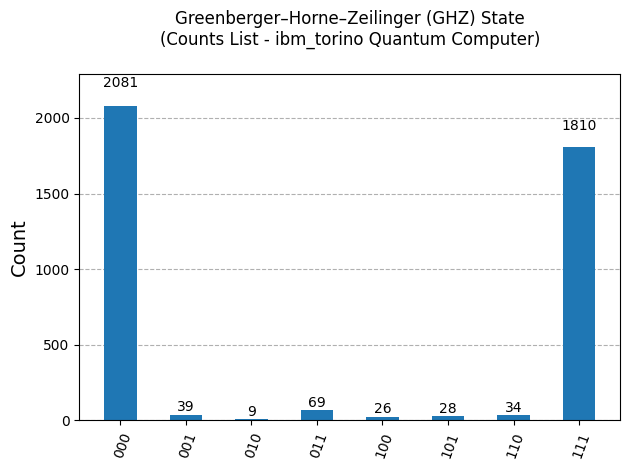

In [28]:
# Step 4. Post-process

# Get the results of the job
# executed from the Sampler 
results_sampler = job.result()

# Retrieve the list of discrete counts of
# the measurements on the results from the Sampler
counts_list = results_sampler[0].data.meas.get_counts()

### YOUR CODE FINISHES HERE    ###


# Print the list of discrete counts (outcomes obtained) of
# the measurements on the results from the Sampler
print(f"  Outcomes for Greenberger–Horne–Zeilinger (GHZ) State:")
print(f"  - {dict(list(counts_list.items())[:4])}")
print(f"    {dict(list(counts_list.items())[4:])}")

# Display the histogram for the list of
# discrete counts (outcomes obtained) of
# the measurements on the results from the Sampler
display(plot_histogram(counts_list,
                       title = f"Greenberger–Horne–Zeilinger (GHZ) State" + \
                               f"\n(Counts List - {backend.name} Quantum Computer)\n"))

# Entanglement

# 1. Espacio de Hilbert y producto tensorial

En mecánica cuántica, el estado de un sistema de múltiples qubits se describe en el producto tensorial de sus espacios de Hilbert individuales.

Para 2 qubits, el espacio total es:  
$$
H = H_A \otimes H_B
$$

Cada qubit vive en un espacio de dimensión 2 (base: $∣0⟩$, $∣1⟩$), así que el sistema total vive en:  
$$
\mathbb{C}^2 \otimes \mathbb{C}^2 = \mathbb{C}^4
$$


### Postulado 1: Estado del sistema

Un sistema cuántico **aislado** está completamente descrito por un **vector de estado** $ \lvert \psi \rangle $ en un espacio de Hilbert complejo $ \mathcal{H} $.

---

 **Aplicación:**

- Para un **solo qubit**, el espacio es:

  $$
  \mathcal{H} = \mathbb{C}^2, \quad \text{con base } \{ \lvert 0 \rangle, \lvert 1 \rangle \}
  $$

- Para **dos qubits**, el espacio total es:

  $$
  \mathcal{H} = \mathbb{C}^2 \otimes \mathbb{C}^2 = \mathbb{C}^4, \quad \text{con base } \{ \lvert 00 \rangle, \lvert 01 \rangle, \lvert 10 \rangle, \lvert 11 \rangle \}
  $$

---

# 2. Estados separables vs entrelazados

### Estado separable:
Un estado es **separable** si puede escribirse como un producto tensorial de estados individuales:

$$
∣ψ⟩ = ∣ψ_A⟩ ⊗ ∣ψ_B⟩
$$

### Estado entrelazado:
Un estado es **entrelazado** si **no puede** escribirse como un producto tensorial de estados individuales.

Por ejemplo, el estado de Bell:

$$
∣Φ⁺⟩ = (1/√2)(∣00⟩ + ∣11⟩)
$$

No puede escribirse como **$∣ψ_A⟩ ⊗ ∣ψ_B⟩$**.  
Esto se puede demostrar directamente (te lo muestro más abajo).


# 3. Construcción del estado entrelazado

Partimos del estado base:

$$
\lvert 00 \rangle = \lvert 0 \rangle \otimes \lvert 0 \rangle
$$

---

### Paso 1: Aplicar Hadamard al primer qubit

La compuerta Hadamard \( H \) transforma:

$$
H \lvert 0 \rangle = \frac{1}{\sqrt{2}} (\lvert 0 \rangle + \lvert 1 \rangle)
$$

Entonces, el estado total se convierte en:

$$
(H \otimes I) \lvert 00 \rangle 
= \left( \frac{1}{\sqrt{2}} (\lvert 0 \rangle + \lvert 1 \rangle) \right) \otimes \lvert 0 \rangle 
= \frac{1}{\sqrt{2}} (\lvert 00 \rangle + \lvert 10 \rangle)
$$

---

### Paso 2: Aplicar compuerta CNOT

La compuerta CNOT toma el **primer qubit como control** y el **segundo como objetivo**:

- $ \text{CNOT}(\lvert 00 \rangle) = \lvert 00 \rangle $  _(no cambia nada)_
- $ \text{CNOT}(\lvert 10 \rangle) = \lvert 11 \rangle $  _(flipa el qubit objetivo)_

Entonces:

$$
\text{CNOT} \left( \frac{1}{\sqrt{2}} (\lvert 00 \rangle + \lvert 10 \rangle) \right) 
= \frac{1}{\sqrt{2}} (\lvert 00 \rangle + \lvert 11 \rangle) 
= \lvert \Phi^+ \rangle
$$


# 4. Demostración de que el estado es entrelazado

Supongamos que el estado de Bell $ \lvert \Phi^+ \rangle $ puede escribirse como un producto de dos estados individuales:

$$
\lvert \Phi^+ \rangle = (a \lvert 0 \rangle + b \lvert 1 \rangle) \otimes (c \lvert 0 \rangle + d \lvert 1 \rangle)
$$

Realizamos el producto tensorial:

$$
\lvert \Phi^+ \rangle = ac \lvert 00 \rangle + ad \lvert 01 \rangle + bc \lvert 10 \rangle + bd \lvert 11 \rangle
$$

Pero sabemos que:

$$
\lvert \Phi^+ \rangle = \frac{1}{\sqrt{2}} (\lvert 00 \rangle + \lvert 11 \rangle)
$$

Comparando ambos lados:

- $ ac = \frac{1}{\sqrt{2}} $
- $ ad = 0 $
- $ bc = 0 $
- $ bd = \frac{1}{\sqrt{2}} $

---

Veamos las implicaciones:

- De $ ad = 0 $, se deduce que $ a = 0 $ o $ d = 0 $
- De $ bc = 0 $, se deduce que $ b = 0 $ o $ c = 0 $

Pero si:
- $ a = 0 $, entonces $ ac = 0 $, contradice $ ac = \frac{1}{\sqrt{2}} $
- $ d = 0 $, entonces $ bd = 0 $, contradice $ bd = \frac{1}{\sqrt{2}} $

No hay combinación de coeficientes $ a, b, c, d \in \mathbb{C} $ que satisfaga todas las ecuaciones al mismo tiempo.

---

**Conclusión:**  
El estado $ \lvert \Phi^+ \rangle $ **no puede escribirse** como un producto de dos estados individuales.  
Por lo tanto, **es un estado entrelazado**.


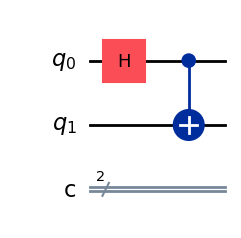

In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_city
import matplotlib.pyplot as plt

## |00⟩ --> |Φ⁺⟩ = (|00⟩ + |11⟩)/√2
# Circuito de 2 qubits

qc = QuantumCircuit(2,2)


# Hadamard en el primer qubit

qc.h(0)

# CNOT: qubit 0 controla, qubit 1 es target

qc.cx(0,1)

# Visualizar circuito

qc.draw('mpl')

In [4]:
# Obtener el estado cuántico resultante

print(Statevector.from_instruction(qc))

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


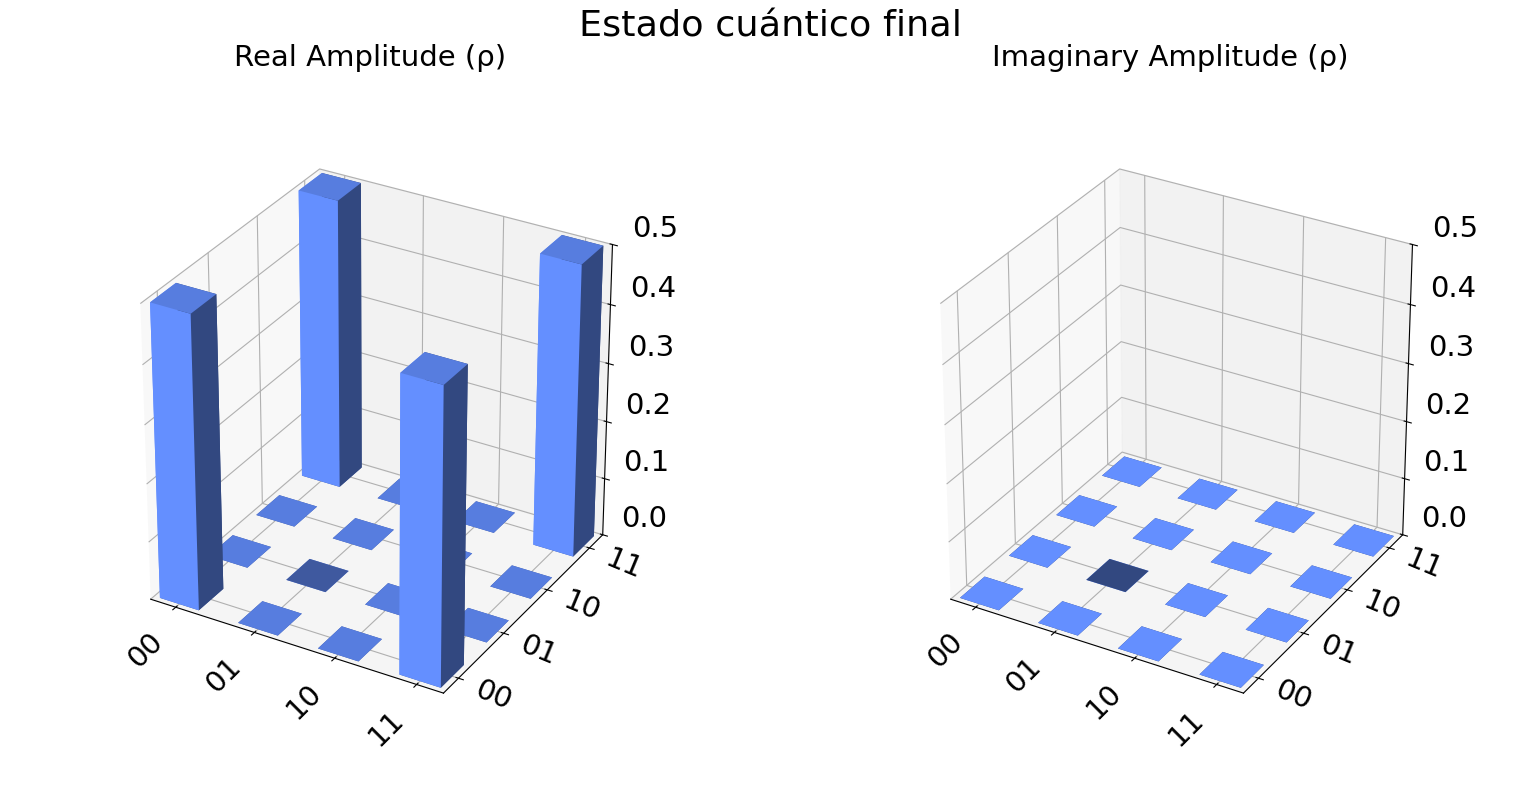

In [5]:
plot_state_city(Statevector.from_instruction(qc), title="Estado cuántico final")

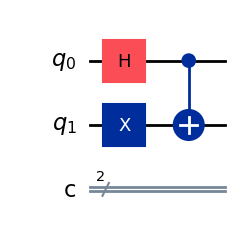

In [9]:
## |01⟩ --> |Ψ⁺⟩ = (|01⟩ + |10⟩)/√2
# Circuito de 2 qubits

qc = QuantumCircuit(2,2)

qc.x(1)

# Hadamard en el primer qubit

qc.h(0)

# CNOT: qubit 0 controla, qubit 1 es target

qc.cx(0,1)

# Visualizar circuito

qc.draw('mpl')

In [10]:
# Obtener el estado cuántico resultante
print(Statevector.from_instruction(qc))

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))


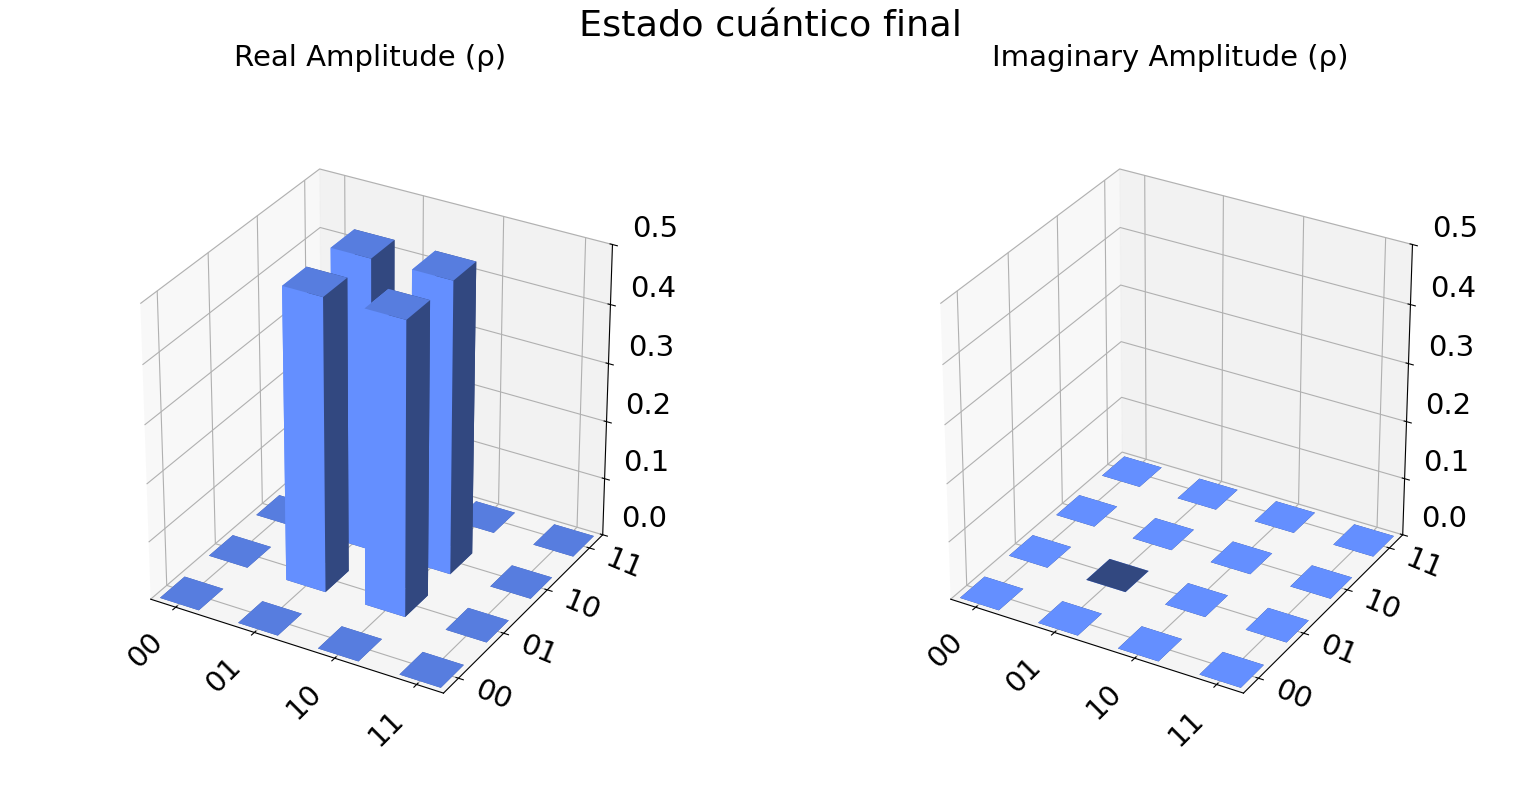

In [11]:
plot_state_city(Statevector.from_instruction(qc), title="Estado cuántico final")

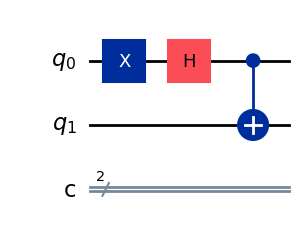

In [16]:
## |10⟩ --> |Φ⁻⟩ = (|00⟩ − |11⟩)/√2
# Circuito de 2 qubits

qc = QuantumCircuit(2,2)

# Hadamard en el primer qubit

qc.x(0)


qc.h(0)

# CNOT: qubit 0 controla, qubit 1 es target

qc.cx(0,1)

# Visualizar circuito

qc.draw('mpl')

In [18]:
# Obtener el estado cuántico resultante
print(Statevector.from_instruction(qc))

Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))


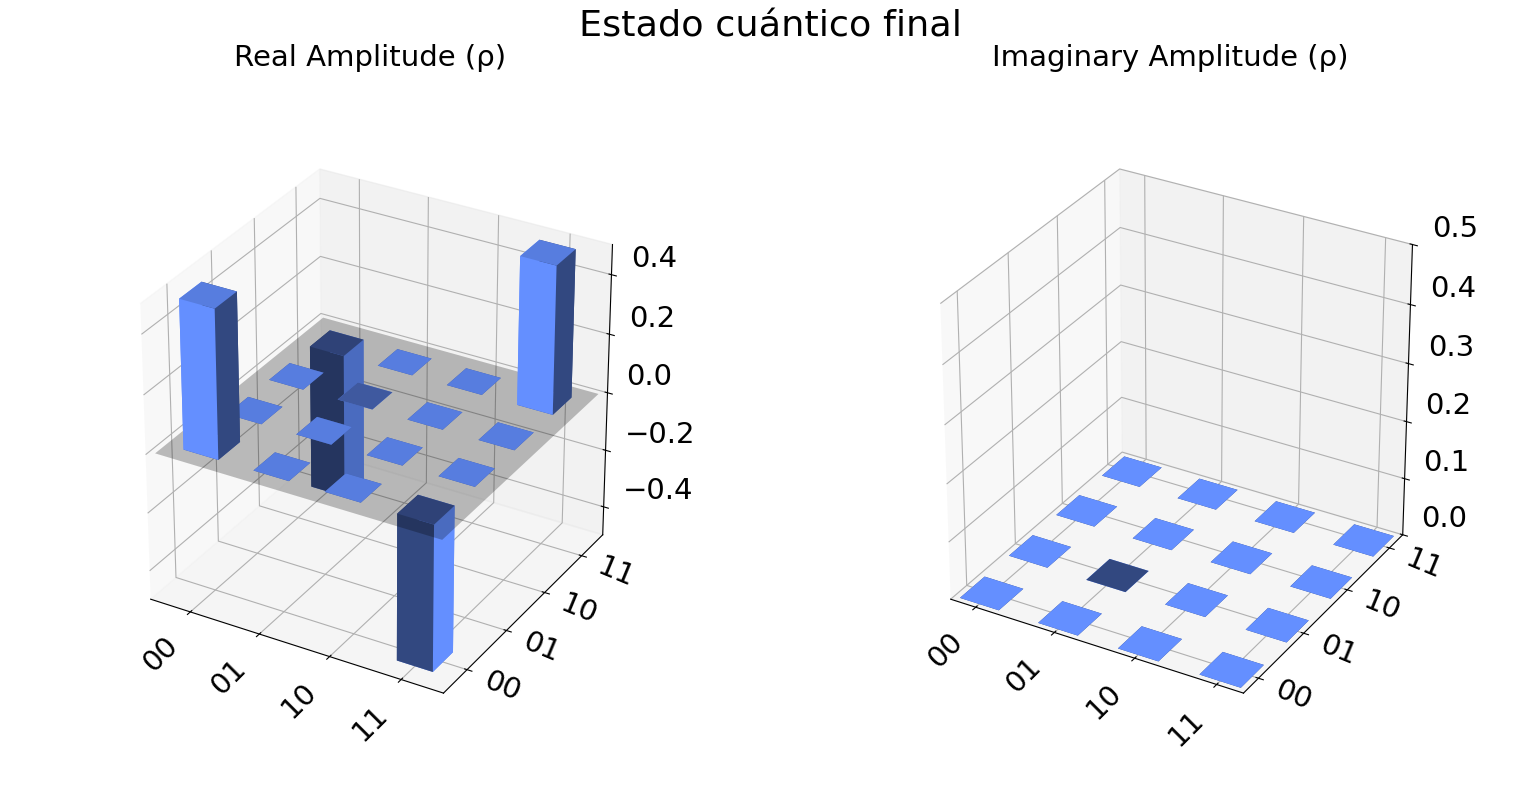

In [19]:
plot_state_city(Statevector.from_instruction(qc), title="Estado cuántico final")

In [ ]:
## |11⟩ --> |Ψ⁻⟩ = (|10⟩ − |01⟩)/√2"
# Circuito de 2 qubits


qc = QuantumCircuit(2,2)

# Hadamard en el primer qubit

qc = 

qc.h(0)

# CNOT: qubit 0 controla, qubit 1 es target

qc.cx(0,1)

# Visualizar circuito

qc.draw('mpl')

In [ ]:
# Obtener el estado cuántico resultante


In [ ]:
plot_state_city(state, title="Estado cuántico final")